In [1]:
import pandas as pd
from CCA_utils import *

## Baseline Model Panel

In [2]:
study_sovereigns = [
    'Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia',
    'Mexico', 'Brazil', 'Egypt', 'Malaysia','Indonesia', 'Philippines', 'Turkey', 'Chile', 'China',
    'South Africa', 'South Korea', 'Thailand']

cca_panel_df = pd.read_csv('../data/processed/CCA/cca_newfx_rates.csv')
cca_panel_df['date'] = pd.to_datetime(cca_panel_df['date'])
cca_panel_df = cca_panel_df[cca_panel_df['country'].isin(study_sovereigns)].copy()
cca_panel_df.drop(columns=['cds_spread_1Y'], inplace=True)
cca_panel_df.rename(columns={'cds_spread_5Y': 'cds_spread'}, inplace=True)


T=1.0
vol_window = 52
freq = 'W'

cca_panel_df['domestic_rate_in_units'] = cca_panel_df['domestic_rate_in_units']/100
cca_panel_df['risk_free_rate'] = cca_panel_df['risk_free_rate']/100
cca_panel_df['monetary_base_mn_localcurr'] = cca_panel_df['monetary_base_mn_localcurr'] / 1000
cca_panel_df['domestic_debt_bn_localcurr'] = cca_panel_df['domestic_debt_bn_localcurr']
cca_panel_df['external_debt_mn_usd'] = cca_panel_df['external_debt_mn_usd']/1000

## M2 Specific data

In [3]:

ovx_df = pd.read_csv('../data/processed/Macroeconomic_variables/OVXCLS.csv')
ovx_df['date'] = pd.to_datetime(ovx_df['date'])

cca_panel_df = cca_panel_df.merge(ovx_df[['date','OVXCLS']], on='date', how='left')

eta = 20 #Jump size parameter J~ -exp(1/eta)
n_paths=5000 #Number of paths for the montecarlo jump simulation
seed = 42
ovxqtl = 0.85


In [5]:
pricer = JumpDiffusionPricer(steps=52, n_paths=n_paths)

results = pd.DataFrame()
for country, group in cca_panel_df.groupby('country'):
    df = group.copy().sort_values('date').reset_index(drop=True)
    
    # --- Unit conversions ---
    r_d = df['domestic_rate_in_units']
    r_f = df['risk_free_rate']
    M_bn = df['monetary_base_mn_localcurr']
    dom_D_bn = df['domestic_debt_bn_localcurr']
    ext_D_bn = df['external_debt_mn_usd']
    fx_rate = df['fx_rate']


    # --- LCL$ ---
    df['LCL_usd'] = [
        compute_lcl_usd(m, bd, fx, rd, rf, T)
        for m, bd, fx, rd, rf in zip(
            M_bn, dom_D_bn, fx_rate, r_d, r_f
        )
    ]

    ann_factor = np.sqrt(52) if freq == 'W' else np.sqrt(12)
    log_ret = np.log(df['LCL_usd'] / df['LCL_usd'].shift(1))
    df['sigma_lcl'] = log_ret.rolling(window=vol_window).std() * ann_factor
    
    # --- Barrier ---
    df['B_f'] = [
            compute_barrier_kvm(debt, rf, T)
            for debt, rf in zip(
                ext_D_bn, r_f
            )
        ]

    df['lamovx'] = np.where(
        df['OVXCLS'] < 30, 0, np.where(df['OVXCLS']<50,0.25,
        np.where(df['OVXCLS']<70, 0.5,1)))
    
        
    # --- Solve CCA for each week ---
    out = {'implied_V': [], 'implied_sigma_V': [], 'cca_converged': [],
           'distance_to_distress': [], 'default_prob': [],
           'model_spread_bps': [], 'put_value': [], 'risky_debt': [],
           'leverage': []}
    
    for i, row in df.iterrows():

        lam_i = row['lamovx']

        cca_base = solve_CCA(row['LCL_usd'], row['sigma_lcl'], row['B_f'],
                                r_f.iloc[i], T)
        
        if lam_i==0:
            risk = compute_risk(cca_base['V'], cca_base['sigma_V'], row['B_f'],
                            r_f.iloc[i], T)
        else:   
            risk = pricer.compute_risk_jd(cca_base['V'], cca_base['sigma_V'], row['B_f'],
                                       r_f.iloc[i], T, lam=lam_i, eta=eta, seed=42)
                # store baseline results...
        out['implied_V'].append(cca_base['V'])
        out['implied_sigma_V'].append(cca_base['sigma_V'])
        out['cca_converged'].append(cca_base['converged'])
        out['distance_to_distress'].append(risk['d2'])
        out['default_prob'].append(risk['default_prob'])
        out['model_spread_bps'].append(risk['credit_spread_bps'])
        out['put_value'].append(risk['put_value'])
        out['risky_debt'].append(risk['risky_debt'])
        out['leverage'].append(risk['leverage'])

    for col, vals in out.items():
        df[col] = vals

    results = pd.concat([results, df])
    print(f"  {country:5s} ")

  Abu Dhabi 
  Brazil 
  Chile 
  China 
  Colombia 
  Dubai 
  Egypt 
  Indonesia 
  Malaysia 
  Mexico 
  Philippines 
  Qatar 
  Saudi Arabia 
  South Africa 
  South Korea 
  Thailand 
  Turkey 


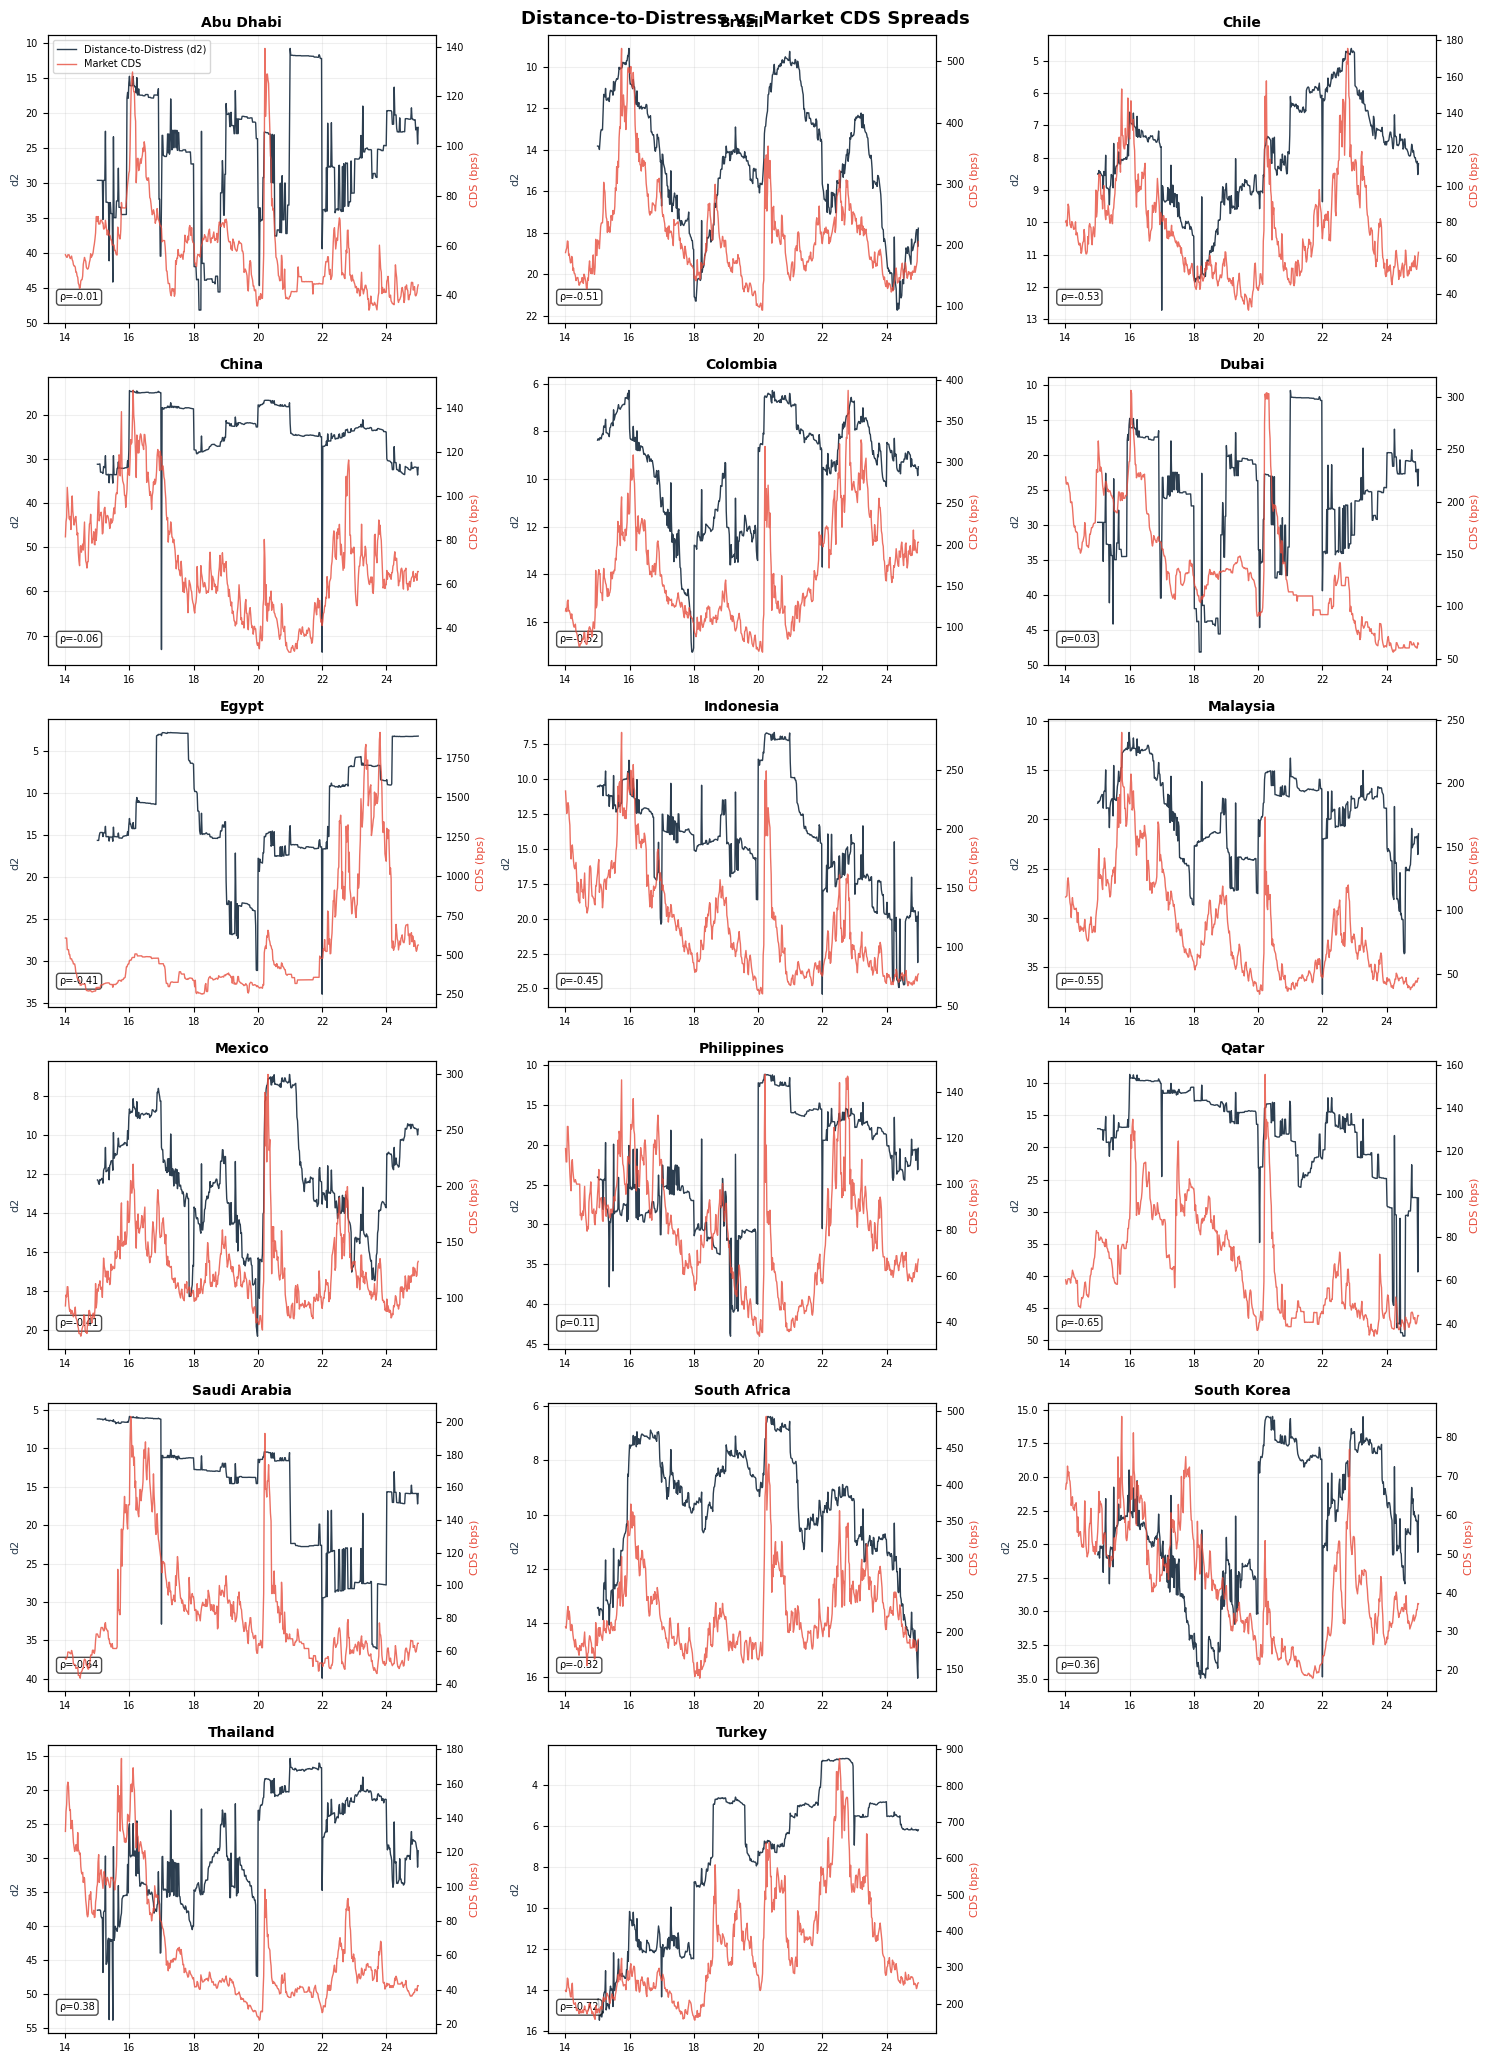

In [6]:
d2_vs_cds = plot_d2_vs_cds(results)

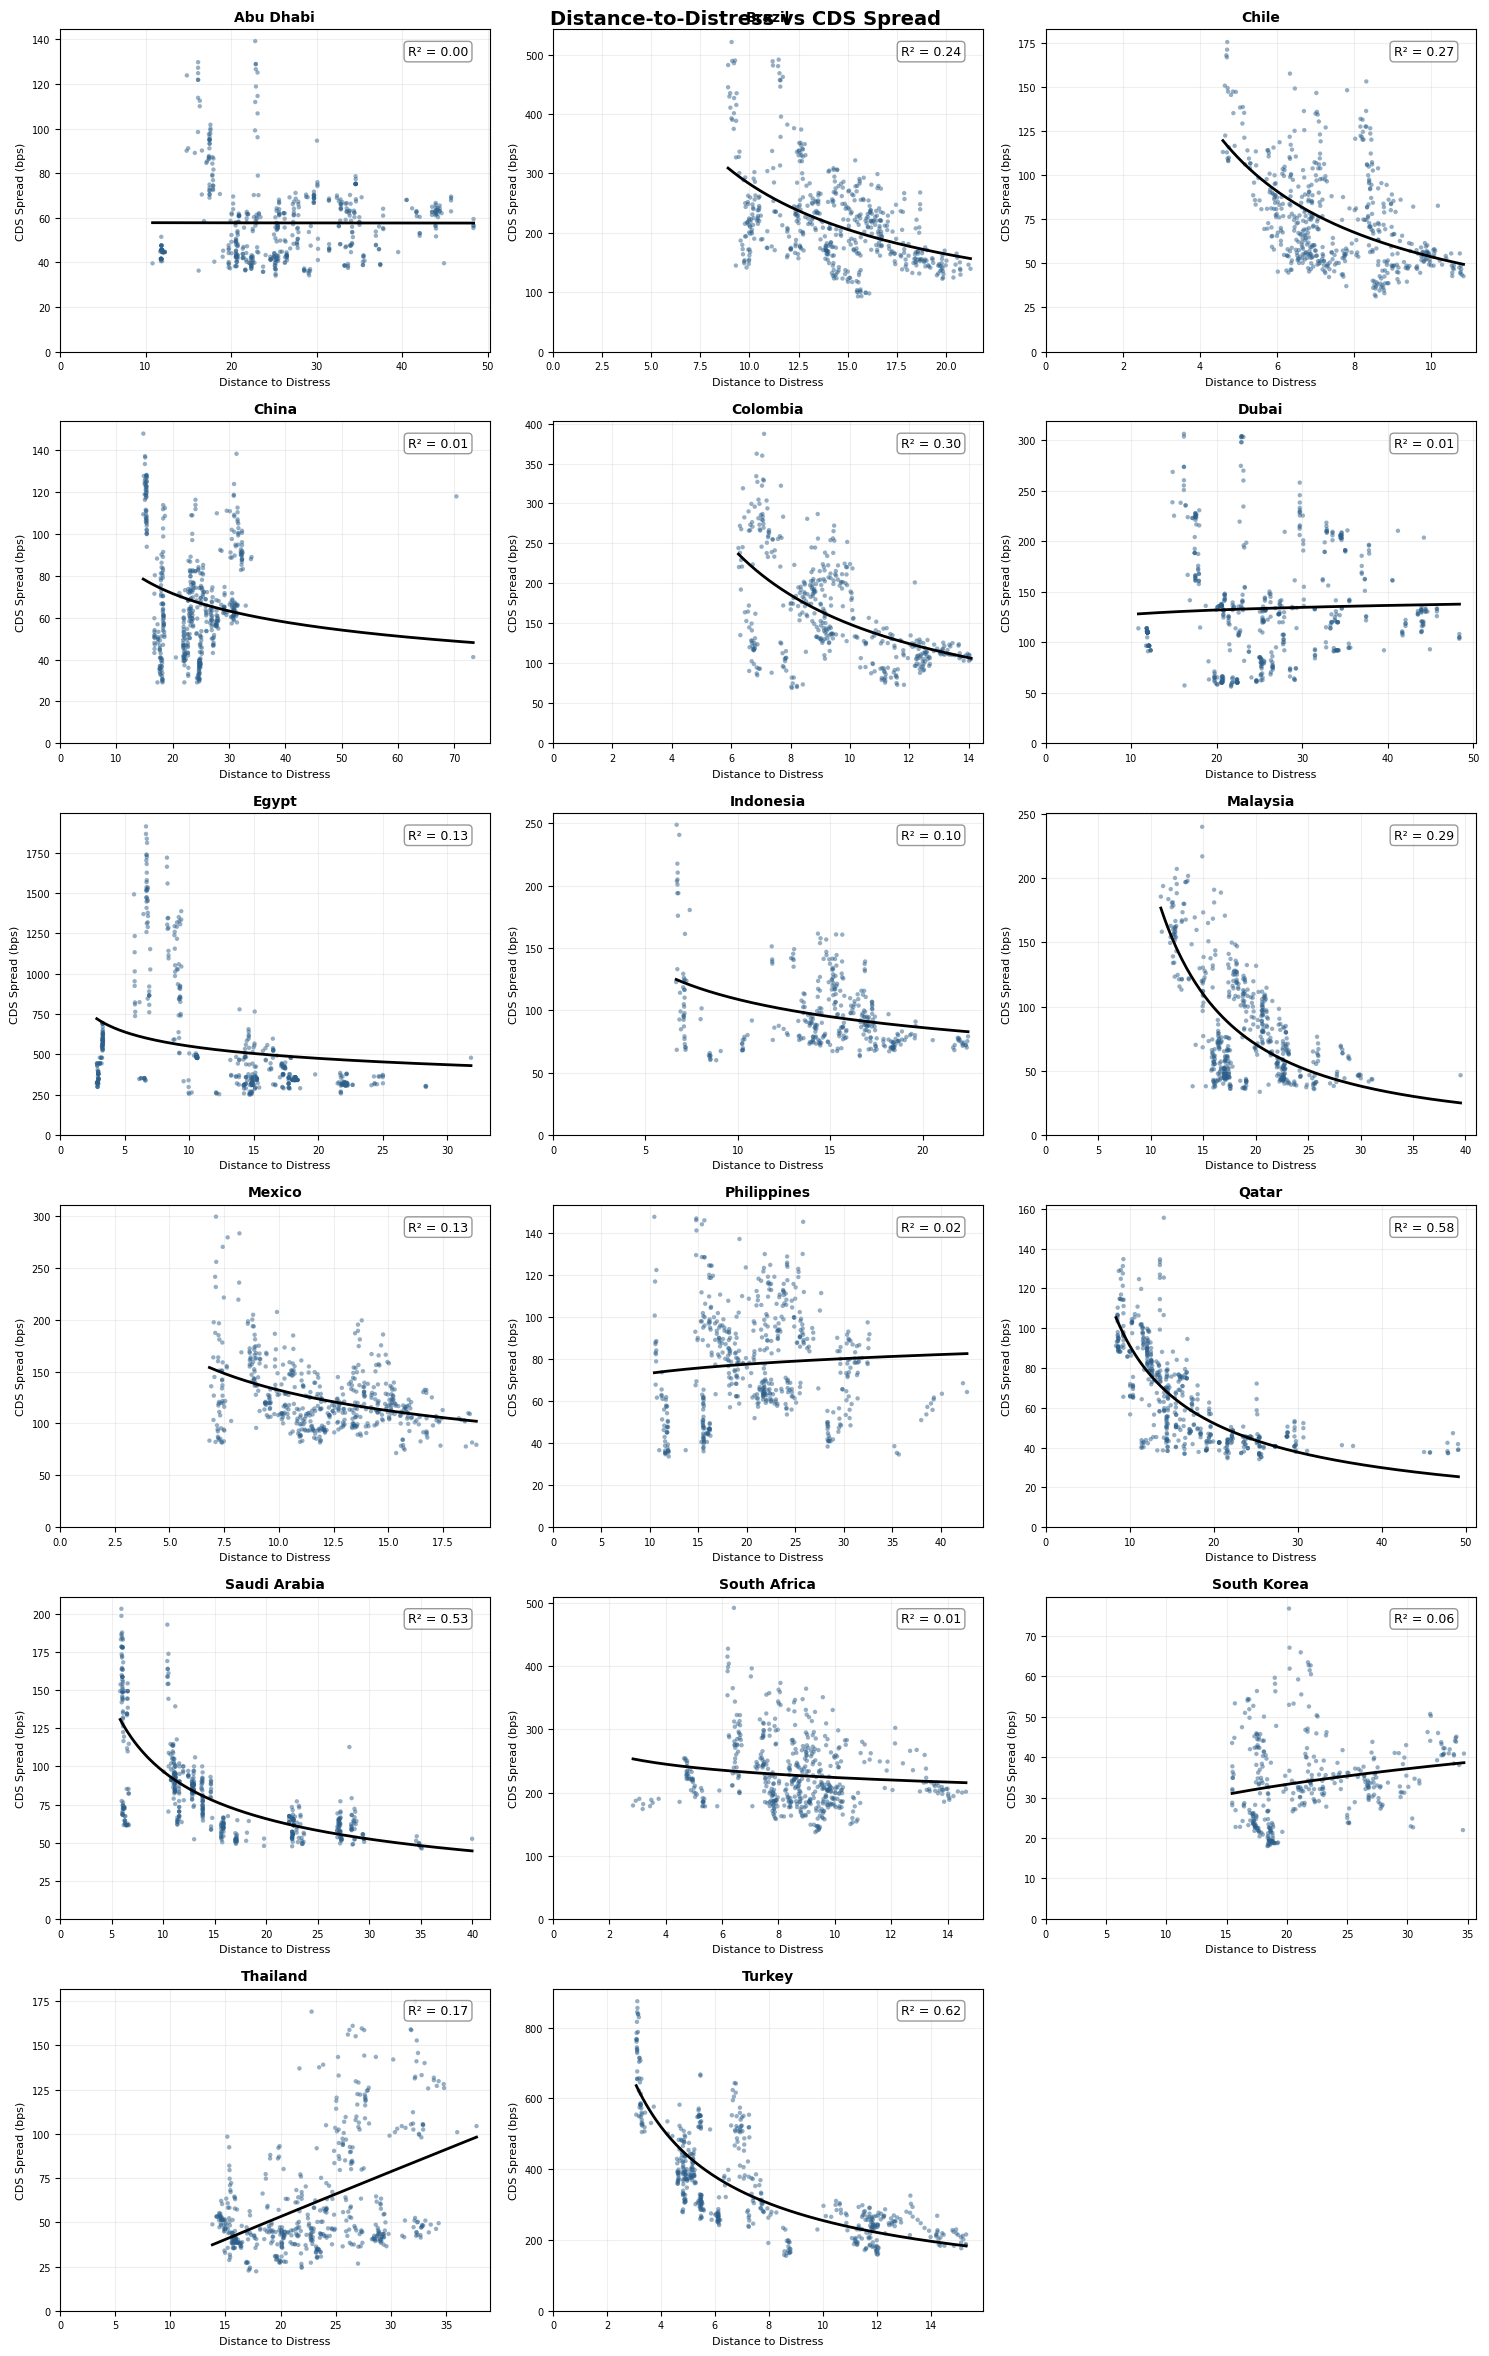

In [5]:
d2_scatter = plot_d2_scatter(results)

In [7]:
display, raw = correlation_table(
    results,
    dd_col='distance_to_distress',
    horizons=[1, 4, 13],
    horizon_labels=['1w', '1m', '3m'],
)
display

,Country,N,ρ (1w),Dir (1w),ρ (1m),Dir (1m),ρ (3m),Dir (3m)
0,Abu Dhabi,522,-0.09*,51%,-0.21***,56%,-0.30***,56%
1,Brazil,522,-0.20***,62%,-0.38***,66%,-0.41***,60%
2,Chile,522,-0.11**,62%,-0.26***,63%,-0.40***,66%
3,China,522,0.00,54%,-0.07,59%,-0.11**,58%
4,Colombia,522,-0.15***,62%,-0.22***,69%,-0.32***,59%
5,Dubai,522,-0.10**,50%,-0.21***,62%,-0.27***,56%
6,Egypt,522,-0.02,55%,0.04,52%,0.01,50%
7,Indonesia,522,-0.07,63%,-0.12***,61%,-0.19***,60%
8,Malaysia,522,-0.08*,62%,-0.21***,63%,-0.40***,64%
9,Mexico,522,-0.24***,59%,-0.43***,58%,-0.54***,62%


In [9]:
results.to_csv("../output/results/M2_results.csv")